<a href="https://colab.research.google.com/github/preethisedigar/data_analytics_projects/blob/main/Small%2BImage%2BClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Small Image Classification Using Convolutional Neural Network (CNN)

We will classify small images cifar10 dataset from tensorflow keras datasets. There are total 10 classes as shown below. We will use CNN for classification


In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt, numpy as np

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# load the dataset

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

In [ ]:
y_test = y_test.reshape(-1,)
y_test

array([3, 8, 8, ..., 5, 1, 7], dtype=uint8)

In [ ]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship', 'truck']

In [ ]:
def plot_samples(X, y, index):
    plt.figure(figsize = (10,5))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index][0]])

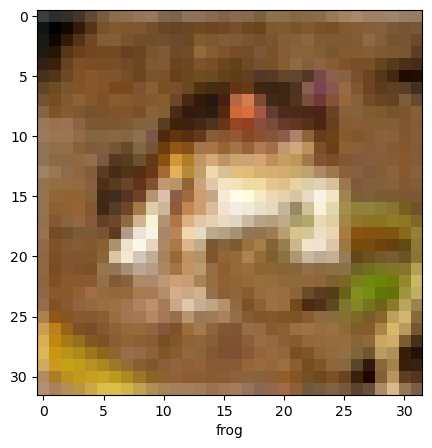

In [ ]:
plot_samples(X_train, y_train, 0)

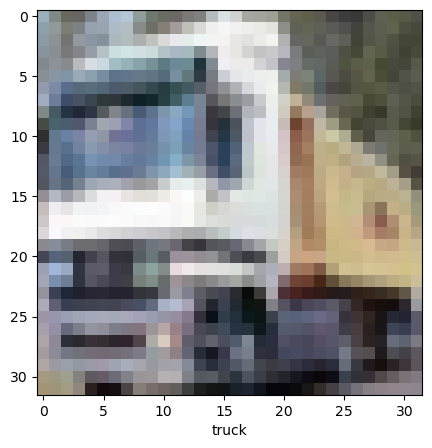

In [ ]:
plot_samples(X_train, y_train, 1)

Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

<h4 style="color:purple">Build simple artificial neural network for image

In [ ]:

ann = models.Sequential([
                        layers.Flatten(input_shape = (32,32,3)),
                        layers.Dense(3000,activation = 'relu'),
                        layers.Dense(1000, activation = 'relu'),
                        layers.Dense(10, activation = 'softmax')
                        ])



In [ ]:
ann.compile(optimizer = 'SGD', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
ann.fit(X_train, y_train, epochs = 5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.3056 - loss: 1.9280
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4224 - loss: 1.6426
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4516 - loss: 1.5523
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4709 - loss: 1.4984
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4958 - loss: 1.4381


**You can see that at the end of 5 epochs, accuracy is at around 49%**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
y_pred = ann.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
y_pred_classes = [np.argmax(element) for element in y_pred]

In [ ]:
y_pred_classes[:5]

[3, 9, 0, 0, 4]

In [ ]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.59      0.52      0.55      1000
           1       0.45      0.77      0.57      1000
           2       0.36      0.43      0.39      1000
           3       0.37      0.30      0.33      1000
           4       0.42      0.43      0.42      1000
           5       0.40      0.39      0.40      1000
           6       0.67      0.31      0.43      1000
           7       0.52      0.58      0.55      1000
           8       0.76      0.42      0.54      1000
           9       0.47      0.60      0.53      1000

    accuracy                           0.47     10000
   macro avg       0.50      0.47      0.47     10000
weighted avg       0.50      0.47      0.47     10000



In [ ]:
print(confusion_matrix(y_test,y_pred_classes))

[[516 104  91  19  32  17   6  42  62 111]
 [ 15 768  10  13  11  15   5  17   9 137]
 [ 56  62 430  65 149  81  27  88  13  29]
 [ 26  77 108 304  71 204  37  79  11  83]
 [ 51  57 173  53 427  57  34 116   7  25]
 [ 26  57 117 162  73 386  25  95  12  47]
 [  5  53 155 121 175  82 313  53  10  33]
 [ 26  66  61  44  60  64   6 576   5  92]
 [143 197  29  15  21  28   2  14 425 126]
 [ 17 272  10  19   9  20  10  32   8 603]]


<h4 style="color:purple">Now let us build a convolutional neural network to train images


In [ ]:
cnn = models.Sequential([
                        layers.Conv2D(filters = 32, kernel_size=(3,3), activation = 'relu',input_shape = (32,32,3)),
                        layers.MaxPooling2D((2,2)),

                        layers.Conv2D(filters = 64, kernel_size=(3,3), activation = 'relu'),
                        layers.MaxPooling2D((2,2)),

                        layers.Flatten(),
                        layers.Dense(64, activation = 'relu'),
                        layers.Dense(10, activation = 'softmax')
])

In [ ]:
cnn.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
cnn.fit(X_train, y_train, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3914 - loss: 1.6785
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6060 - loss: 1.1274
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6621 - loss: 0.9745
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6959 - loss: 0.8846
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7176 - loss: 0.8182
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7399 - loss: 0.7542
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7555 - loss: 0.7082
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7716 - loss: 0.6581
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7848 - loss: 0.6160
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7969 - loss: 0.5812


**With CNN, at the end 5 epochs, accuracy was at around 70% which is a significant improvement over ANN. CNN's are best for image classification and gives superb accuracy. Also computation is much less compared to simple ANN as maxpooling reduces the image dimensions while still preserving the features**

In [ ]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6912 - loss: 0.9126


[0.9228047132492065, 0.6947000026702881]

In [ ]:
y_pred = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred[:5]

array([[5.97574341e-04, 6.53890165e-05, 7.62632815e-03, 7.71091402e-01,
        6.55679591e-03, 9.33945850e-02, 1.23372674e-02, 6.57539640e-05,
        1.08104579e-01, 1.60368130e-04],
       [1.11555588e-03, 5.16944766e-01, 1.24399230e-06, 2.97193878e-06,
        1.91724183e-08, 1.82078985e-09, 2.63277178e-09, 6.38867625e-09,
        4.49498773e-01, 3.24365832e-02],
       [4.22418257e-03, 3.01877130e-02, 6.62755556e-05, 1.33783754e-03,
        1.25072183e-04, 8.68705101e-05, 6.47610359e-05, 4.05152328e-04,
        9.58540261e-01, 4.96186502e-03],
       [9.04142201e-01, 1.97930518e-03, 2.07484830e-02, 6.12076931e-03,
        3.49802012e-03, 5.18202660e-06, 1.06433945e-04, 1.47081533e-04,
        6.31517470e-02, 1.00782032e-04],
       [1.24697965e-06, 1.62143148e-02, 1.43046649e-02, 4.31457255e-03,
        1.61940128e-01, 2.27845623e-03, 8.00681114e-01, 8.36566358e-07,
        2.61156267e-04, 3.47785681e-06]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]

In [ ]:
y_classes[:5]

[3, 1, 8, 0, 6]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [ ]:
classes[y_classes[3]]

'airplane'

In [ ]:
print(classification_report(y_test, y_classes))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75      1000
           1       0.79      0.84      0.81      1000
           2       0.61      0.60      0.61      1000
           3       0.48      0.55      0.51      1000
           4       0.65      0.57      0.61      1000
           5       0.67      0.50      0.57      1000
           6       0.65      0.86      0.74      1000
           7       0.78      0.71      0.74      1000
           8       0.78      0.84      0.81      1000
           9       0.83      0.72      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



In [ ]:
print(confusion_matrix(y_test,y_classes))

[[746  23  44  29  19   2  22   8  88  19]
 [ 22 840   8  10   3   3  13   6  27  68]
 [ 58   9 604  70  70  33 104  27  18   7]
 [ 18  12  63 553  73 114 105  27  23  12]
 [ 20  10  91  84 571  27 129  56  10   2]
 [  9   4  87 229  43 503  51  49  17   8]
 [  6   7  24  57  20  10 860   6   9   1]
 [ 19   9  44  70  64  45  20 710   7  12]
 [ 61  37  15  16   5   5   4   4 837  16]
 [ 30 117  16  31   4   9  12  18  40 723]]


Misclassification in image files during machine learning tasks typically occurs due to reasons related to **data quality, model limitations, or the nature of the task itself**. It is rarely caused by human data entry errors but rather by a combination of technical and contextual factors.

Here are the main reasons why misclassification happens:

---

### 1. **Data-Related Issues**
#### a. **Incorrect Labels (Human Error or Ambiguity)**
   - Sometimes, labels in the dataset are incorrect due to human mistakes during annotation or due to the inherent ambiguity of the image.
   - Example: A cat labeled as a dog because the annotator made an error.

#### b. **Class Ambiguity**
   - Some images may have features that overlap between classes, making it difficult to classify them correctly.
   - Example: A close-up of a lion's fur may be confused with a tiger's.

#### c. **Insufficient Data**
   - If the training dataset lacks diversity, the model may fail to generalize. For instance:
     - Images are too similar.
     - Some classes are underrepresented (class imbalance).
   - Example: A model trained on sunny-day road scenes might fail to classify snowy or rainy road images.

#### d. **Poor Quality of Images**
   - Blurry, low-resolution, or overexposed images can make feature extraction harder.
   - Example: A blurry image of a handwritten digit may confuse the model.

---

### 2. **Model-Related Issues**
#### a. **Overfitting**
   - If the model memorizes the training data instead of learning general patterns, it may fail to classify unseen images correctly.
   - Example: A model trained to recognize cars might misclassify a truck because it hasn't learned generalized vehicle features.

#### b. **Underfitting**
   - A model that is too simple or lacks sufficient training may fail to learn meaningful patterns in the data.
   - Example: Using a linear model to classify complex images like CIFAR-10.

#### c. **Inadequate Architecture**
   - Using a model architecture (e.g., ANN instead of CNN) that is not well-suited for image tasks can lead to poor performance.
   - Example: An ANN doesn't capture spatial relationships in images like a CNN does.

#### d. **Incorrect Hyperparameters**
   - Poor choices in learning rate, number of epochs, or optimization algorithms can lead to suboptimal learning.

---

### 3. **Environmental or Task-Related Challenges**
#### a. **Occlusion**
   - Parts of the image are blocked or hidden.
   - Example: A dog partially obscured behind a fence might be misclassified.

#### b. **Background Noise**
   - Complex or noisy backgrounds can confuse the model.
   - Example: A bird on a colorful background might not be recognized as a bird.

#### c. **Similar Features Across Classes**
   - Certain classes may share visual similarities, making classification difficult.
   - Example: Wolves and huskies look very similar; a wolf in a snowy background may be classified as a husky.

#### d. **Perspective Changes**
   - Images taken from unusual angles might lead to incorrect classifications.
   - Example: A car photographed from the top may not be recognized as a car.

---

### 4. **Testing Issues**
#### a. **Domain Shift**
   - Training and testing datasets come from different distributions.
   - Example: A model trained on grayscale images might misclassify colored images.

#### b. **Adversarial Attacks**
   - Subtle changes to the image (often imperceptible to humans) can cause a model to misclassify.
   - Example: Adding noise to an image of a cat might lead to its misclassification as a dog.

---

### How to Mitigate Misclassification:
1. **Improving Data Quality:**
   - Ensure high-quality, well-labeled, and diverse datasets.
   - Augment the dataset with transformations (e.g., rotations, flips) to increase diversity.

2. **Choosing Appropriate Models:**
   - Use advanced architectures like CNNs or pre-trained models (e.g., ResNet, VGG) for image tasks.

3. **Handling Ambiguity:**
   - Use multiple annotators for labeling and resolve inconsistencies with majority voting.

4. **Training Properly:**
   - Tune hyperparameters (e.g., learning rate, batch size).
   - Use techniques like regularization or dropout to prevent overfitting.

5. **Addressing Class Imbalance:**
   - Use weighted loss functions or oversample underrepresented classes.

---

### Conclusion:
Misclassification in image datasets usually arises from a combination of **data issues, model limitations, and the inherent challenges of the task**. While human error in labeling does happen, it's just one of many factors contributing to misclassification.



Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs) differ in their structure, purpose, and mathematical operations. Here's a breakdown of their differences in **terms of code and formulas**:

---

## 1. **Artificial Neural Networks (ANNs)**

### Purpose:
- ANNs are primarily used for structured data (e.g., tabular datasets) or simple tasks like regression and classification.
- They use fully connected layers where every neuron in one layer is connected to every neuron in the next layer.

### Code Example:
```python
from tensorflow.keras import models, layers

# ANN with fully connected layers
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),  # Flattens the input image into a vector
    layers.Dense(128, activation='relu'),    # Fully connected hidden layer
    layers.Dense(64, activation='relu'),     # Another fully connected hidden layer
    layers.Dense(10, activation='softmax')   # Output layer for classification
])
```

### Formulas:
1. **Forward Propagation**:
   - For a single layer:
     \[
     Z = W \cdot X + b
     \]
     \[
     A = f(Z)
     \]
     Where:
     - \( Z \): Weighted sum
     - \( W \): Weight matrix
     - \( X \): Input data
     - \( b \): Bias
     - \( f(Z) \): Activation function (e.g., ReLU, Sigmoid)

2. **Backpropagation**:
   - Update weights using gradients:
     \[
     W = W - \eta \frac{\partial L}{\partial W}
     \]
     Where:
     - \( \eta \): Learning rate
     - \( L \): Loss function

---

## 2. **Convolutional Neural Networks (CNNs)**

### Purpose:
- CNNs are designed to work with image data. They capture spatial hierarchies in images using convolutional layers.
- Instead of fully connected layers for feature extraction, they use convolutional and pooling layers.

### Code Example:
```python
from tensorflow.keras import models, layers

# CNN with convolutional and pooling layers
cnn = models.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),  # Downsampling
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),                        # Flatten before dense layers
    layers.Dense(64, activation='relu'),     # Fully connected layer
    layers.Dense(10, activation='softmax')   # Output layer
])
```

### Formulas:
1. **Convolution Operation**:
   - Instead of \( Z = W \cdot X + b \), CNNs compute:
     \[
     Z[i, j, k] = \sum_{m,n,c} W[m, n, c, k] \cdot X[i+m, j+n, c] + b[k]
     \]
     Where:
     - \( W[m, n, c, k] \): Filter (kernel)
     - \( X[i+m, j+n, c] \): Input patch
     - \( b[k] \): Bias for the \( k \)-th filter
     - \( Z[i, j, k] \): Convolution output (feature map)

2. **Pooling Operation**:
   - For max pooling:
     \[
     P[i, j, k] = \max(X[i:i+p, j:j+p, k])
     \]
     Where \( p \) is the pooling window size.

3. **Backpropagation**:
   - Similar to ANNs, but gradients are calculated for both convolutional and fully connected layers.

---

## Key Differences in Code and Formulas:
| Aspect                | **ANN**                                               | **CNN**                                                   |
|-----------------------|-------------------------------------------------------|----------------------------------------------------------|
| **Input**             | Flattened vectors (e.g., \( (32, 32, 3) \rightarrow 3072 \)) | Maintains spatial dimensions (e.g., \( (32, 32, 3) \))      |
| **Layers**            | Fully connected layers (`Dense`)                      | Convolutional layers (`Conv2D`) and pooling layers (`MaxPooling2D`) |
| **Feature Extraction**| Manual or implicit                                   | Automatic with convolutional filters                     |
| **Formulas**          | \( Z = W \cdot X + b \)                               | Convolution: \( Z[i,j,k] = \sum W \cdot X + b \)         |
| **Use Case**          | Structured/tabular data                               | Image, video, or spatial data                            |

---

### Summary:
- **ANNs** are simpler and work on flattened input, using fully connected layers for learning.
- **CNNs** use convolutional filters to extract spatial features from images, making them well-suited for image-related tasks.